# PowerPlant

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("powerplant_data.csv")

X = df.drop("PE", axis=1)
y = df["PE"]

In [2]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [5]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [6]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# ANN 

In [7]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            nn.Linear(6, 6),
            nn.ReLU(),

            nn.Linear(6, 1),
        )
    def forward(self, x):
        return self.model(x)

In [8]:
import torch.optim as optim
model = ANN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [9]:
train_loss = []
val_loss = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:     # xb -> feat of 1 batch, yb -> label of 1 batch
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        output = model(xb)

        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()     #loss ia s tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            output = model(xb)

            loss = criterion(output, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/ len(test_loader)
    val_loss.append(epoch_val_loss)

    print(f"epoch = {epoch+1}/{epochs} => train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch = 1/100 => train loss = 205881.41666666666 & val loss = 203380.31927083334
epoch = 2/100 => train loss = 195825.18678385418 & val loss = 183424.04140625
epoch = 3/100 => train loss = 160890.16409505208 & val loss = 133381.38619791667
epoch = 4/100 => train loss = 102791.21271158854 & val loss = 74539.713671875
epoch = 5/100 => train loss = 54375.064290364586 & val loss = 38791.01331380208
epoch = 6/100 => train loss = 29356.14345703125 & val loss = 22197.132942708333
epoch = 7/100 => train loss = 18239.326741536457 & val loss = 15180.8740234375
epoch = 8/100 => train loss = 13373.579217529297 & val loss = 11737.363826497396
epoch = 9/100 => train loss = 10377.816357421874 & val loss = 9003.2798828125
epoch = 10/100 => train loss = 7779.879879760742 & val loss = 6606.640600585937
epoch = 11/100 => train loss = 5574.579941813151 & val loss = 4633.211857096354
epoch = 12/100 => train loss = 3860.8633473714194 & val loss = 3227.338142903646
epoch = 13/100 => train loss = 2716.0921183

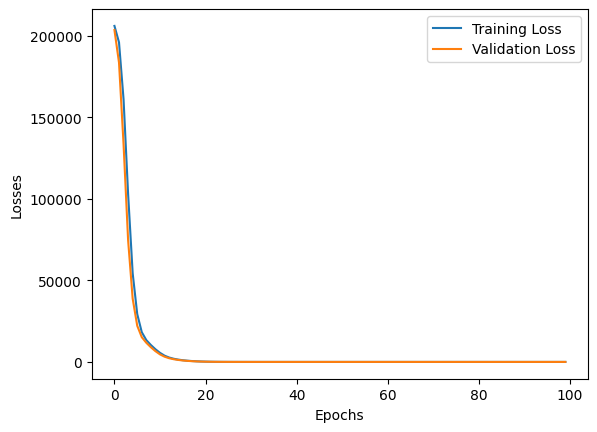

In [10]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_loss,
    "Validation Loss" : val_loss
})
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

# loading the best model 

In [12]:
model.load_state_dict(torch.load("best_model.pt"))

# evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor.to(device))
    test_preds = model(X_test_tensor.to(device))

    train_mse_loss = criterion(train_preds, y_train_tensor.to(device))
    test_mse_loss = criterion(test_preds, y_test_tensor.to(device))

print("Training MSE : ", train_mse_loss.item())
print("Test MSE : ", test_mse_loss.item())

Training MSE :  20.70742416381836
Test MSE :  18.956809997558594


In [14]:
from sklearn.metrics import r2_score
print("R^2 score : ", r2_score(y_test, test_preds.cpu().numpy()))

R^2 score :  0.9337508461467772


## To compare predicted vs actual

In [17]:
predicted_df = pd.DataFrame(test_preds.cpu().numpy(), columns=["Predictes Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predictes Values,Actual Values
0,434.721283,433.27
1,436.644775,438.16
2,461.731506,458.42
3,476.863403,480.82
4,435.411133,441.41
...,...,...
1909,451.013123,456.70
1910,431.193909,438.04
1911,467.466888,467.80
1912,430.710083,437.14
